##### 로지스틱회귀 ==> 분류모델 (예측모델X)
'''
공부한 시간 데이터를 보고 합격여부를 예측
공부시간에 비례해서 점수를 부여
공부 1시간에 10점을 부여
--> 선형 방정식
합격점수(z) = w*(공부시간)+b
w(가중치) : 중요도 1시간당 점수 (10점)
b(편향) : 기본점수(-50, 5시간 공부해야 0점)

문제점 : 합격점수에 해당하는 100점이 나올수도 있지만 -200점이 나올수도 있음..
분류를 하려면 즉 합격 불합격 판단해야하는데, 우리가 원하는 것은 방정식의 값으로 확률을 계산하고 싶음 (0~100% 사이값)
'''
# ==> 점수를 확률로 바꿔야한다. (시그모이드 함수 : 0~1사이 값으로 변경)
# 로지스틱회귀에서는 시그모이드 함수가 적용되어 있음.
# 확률값을 가지고 분류 ==> 분류모델
'''
합격 확률 = 시그모이드(z) = 1/1 + e^-z
합격 점수가 높으면 1에 가깝고, 낮으면 0에 가까움
합격 점수가 0이면 정확히 0.5(50%) - 임계값
'''

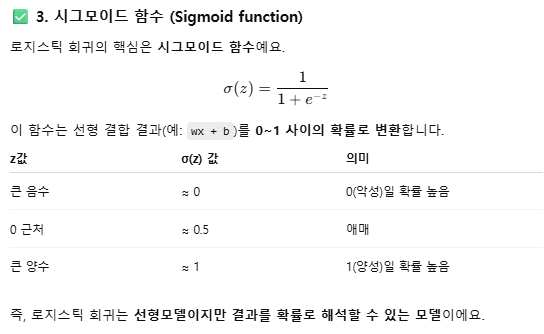

In [ ]:
# 비용함수 (손실함수) : 모델이 얼마나 틀렸는지 측정 / 로지스틱은 로그함수를 사용
'''
합격 (정답=1)으로 가정,
모델이 99% 합격예측 ==> 벌점은 거의 0점
모델이 1% 합격예측 ==> 별점은 크게(무한대에 가깝게)

불합격 (정답=0)으로 가정,
모델이 1%로 합격을 예측 ==> 잘 맞춤 => 벌점이 거의 0점
모델이 99%로 합격을 예측 ==> 완전 틀림 => 벌점을 아주 크게

log loss 원리 
: 손실함수를 이용해서 벌점(손실)이 가장 작아지도록 w(가중치),b(절편)를 찾음(조정).

'''

# 비용이 최저인 값을 찾아나가는 과정 : 경사하강법

# 너무 완벽한 모델 (과적합 over fitting 👉 “훈련 데이터는 완벽히 맞추지만, 실제 상황에서는 망함!”)
'''
규제(Regularization) : 모델이 너무 복잡해지지 않도록 패널티 또는 단순함에 대한 보너스
L2규제(Ridge) : w(중요도)값이 너무커지는 것을 막는다 => 가중치(w) 제곱의 합을 패널티로 추가
L1규제(Lasso) : 어떤 특징이 별로 안중요할 것 같으면, 그냥 w(중요도)를 0으로 만듬. 
                => 불필요한 특징을 제거하는 효과 => 가중치들의 절대값의 합을 패널티로 추가
                => feature selector 역할도 겸함
'''


'\n규제(Regularization) : 모델이 너무 복잡해지지 않도록 패널티 또는 단순함에 대한 보너스\nL2규제(Ridge) : w(중요도)값이 너무커지는 것을 막는다 => 가중치(w) 제곱의 합을 패널티로 추가\nL1규제(Lasso) : 어떤 특징이 별로 안중요할 것 같으면, 그냥 w(중요도)를 0으로 만듬. \n                => 불필요한 특징을 제거하는 효과 => 가중치들의 절대값의 합을 패널티로 추가\n                => feature selector 역할도 겸함\n'

In [ ]:
# 로지스틱 회귀 모델의 예측값과 확률값을 확인
# “모델이 단순히 어떤 클래스를 골랐는지(0/1)”뿐 아니라
# “얼마나 자신 있게 그 클래스를 골랐는지(확률)”도 볼 수 있는 코드예요.


from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
data = load_breast_cancer()
# LogisticRegression() 기본 설정은 max_iter=100입니다.
# 유방암 데이터는 피처 수가 30개라 기본 반복 횟수로는 수렴하지 않을 가능성이 있어요.
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.3)
clr=LogisticRegression(max_iter=1000)
clr.fit(X_train,y_train)
predict = clr.predict(X_test)
print(f' 최종예측 (0 또는 1) : {predict[:5]}, 실제 값 : {y_test[:5]}')
predict_proba = clr.predict_proba(X_test)
print(f' 각 클래스 확률 : {predict_proba[:5]}')

# prediect 클래스 예측 0/1
# predict_proba()는 확률 예측
    # 각 행은 한 샘플(사람)
    # 두 개의 숫자는 [악성일 확률, 양성일 확률] 0: malignant (악성) 1: benign (양성)
    # 예: [0.02, 0.98] → “양성일 확률이 98%”

 최종예측 (0 또는 1) : [1 1 0 1 0], 실제 값 : [1 1 0 1 0]
 각 클래스 확률 : [[7.08855911e-04 9.99291144e-01]
 [3.64906313e-03 9.96350937e-01]
 [9.99999870e-01 1.30232549e-07]
 [1.88563653e-03 9.98114363e-01]
 [9.99999487e-01 5.12631237e-07]]


c:\Users\playdata2\miniconda3\envs\deep\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# --- 시각화 함수 (공통) ---
def plot_decision_boundary(model, X_orig, y_orig, poly_transformer, scaler_transformer, title, subplot_ax):
    """모델의 결정 경계를 그려주는 함수"""
    # 1. 그래프를 그릴 영역을 정의합니다.
    x_min, x_max = X_orig[:, 0].min() - 0.5, X_orig[:, 0].max() + 0.5
    y_min, y_max = X_orig[:, 1].min() - 0.5, X_orig[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # 2. 그래프 영역의 모든 점들을 모델이 예측할 수 있도록 변환합니다.
    grid_poly = poly_transformer.transform(np.c_[xx.ravel(), yy.ravel()])
    grid_scaled = scaler_transformer.transform(grid_poly)

    # 3. 변환된 점들을 모델로 예측합니다.
    Z = model.predict(grid_scaled)
    Z = Z.reshape(xx.shape)

    # 4. 결정 경계와 원본 데이터 포인트를 그립니다.
    subplot_ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    subplot_ax.scatter(X_orig[:, 0], X_orig[:, 1], c=y_orig, cmap=plt.cm.coolwarm, edgecolors='k')
    subplot_ax.set_title(title)
    subplot_ax.set_xlabel("Feature 1")
    subplot_ax.set_ylabel("Feature 2")

In [ ]:
# 과적합 모델을 임의로 만들어서 시각화
# 1. 규제 알고리즘을 적용
# 2. 모델을 경량화 .. 모델의 복잡도를 높이는 요소를 제거 
# 3. 추가 데이터를 투입해서 학습

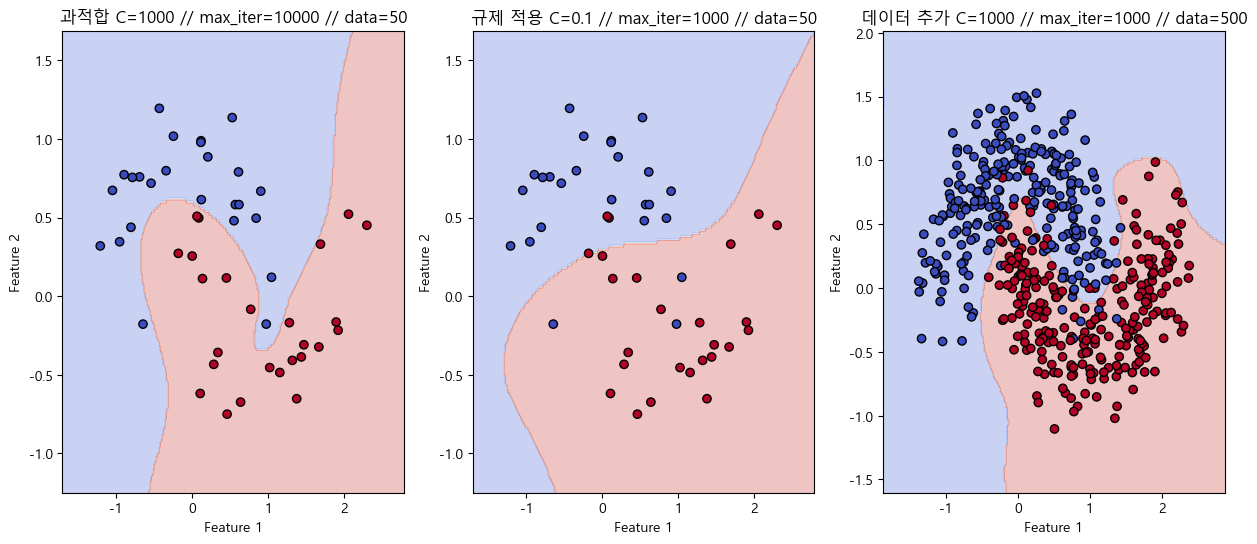

In [ ]:
####### 임의의 과적합 모델 만들기

import matplotlib as mpl
mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1,3, figsize=(15,6))


# case1. 데이터 적게 과적합
X_small, y_small = make_moons(n_samples=50, noise=0.25, random_state=45)

# 고차항 특성으로 변환 (과적합 유도)
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_small = poly.fit_transform(X_small)

#데이터 스케일링
scaler = StandardScaler()
X_scaled_small = scaler.fit_transform(X_poly_small)

# 모델 훈련
log_reg_overfit = LogisticRegression(C=1000, max_iter=10000, random_state=45) #C가 규제강도. 클수록 규제를 약하게/ max_iter는 학습횟수
log_reg_overfit.fit(X_scaled_small, y_small)
# 시각화
plot_decision_boundary(log_reg_overfit, X_small, y_small, poly, scaler, '과적합 C=1000 // max_iter=10000 // data=50', axes[0])



# case2. 규제 적용 (데이터 50개에 대해 강한 규제를 적용)
log_reg_regulation = LogisticRegression(C=0.1, max_iter=1000, random_state=45)
log_reg_regulation.fit (X_scaled_small, y_small)
# 시각화
plot_decision_boundary(log_reg_regulation, X_small, y_small, poly, scaler, '규제 적용 C=0.1 // max_iter=1000 // data=50', axes[1])




# case3. 데이터를 추가 (데이터 500, 약하게)
X_large, y_large = make_moons(n_samples=500, noise=0.25, random_state=45)
# 고차항 특성으로 변환 (과적합 유도)
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_large = poly.fit_transform(X_large)
#데이터 스케일링
scaler = StandardScaler()
X_scaled_large = scaler.fit_transform(X_poly_large)
# 모델 훈련
log_reg_moredata = LogisticRegression(C=1000, max_iter=10000, random_state=45) #C가 규제강도. 클수록 규제를 약하게/ max_iter는 학습횟수
log_reg_moredata.fit(X_scaled_large, y_large)
# 시각화
plot_decision_boundary(log_reg_moredata, X_large, y_large, poly, scaler, '데이터 추가 C=1000 // max_iter=1000 // data=500', axes[2])


# case 1 . ax[0] 학습데이터에 너무 치중해서(over fitting) 일반화 능력이 떨어짐.
# ==> 상기 과적합 모델에 규제를 줌. ax[1] case2
# case 3. 데이터를 500개로 더 줌. 
#       ==> 몇몇 색을 과하게 구분하지 않고 (파란색을 빨간색 지역에 있더라도 넘어가는..) 해서
          # 원래 moon 모양으로 분류가능함

In [ ]:
# 파이프라인 적용 ???????  ==== DJ 작성 / 답모름
from sklearn.pipeline import Pipeline
X,y = make_moons(n_samples=500, noise=0.25, random_state=45)
X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y, test_size=0.3, random_state=42)
pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('clssifier', LogisticRegression(random_state=42, max_iter=10000))
    ])
pipe.fit(X_train, y_train)  #pipe는 scalar 을 알아서 해줌 
pipe.score(X_test, y_test)

0.8266666666666667

In [ ]:
# ROC, AUC
'''
정확도 99% 하지만, 데이터가 불균형이라면 좋은 척도가 되지 못함. 
ROC, AUC 얼마나 안정적으로 좋은 성능을 내는지를 종합적으로 시각화.
모델이 예측한 확률을 기반으로 분류기준점(Theshold)을 계속 변경해서 모델의 성능이 어떻게 변화하는지 하나의 곡선으로
'''

# ROC 구성요소 TPR FPR
'''
혼동행렬 (p(암환자):1, n(정상):0)
    (답 / 예측)
TP (True Positive) : 진짜 암환자를 암이라고 예측 / 정답
FN (False Negative) : 진짜 암환자를 정상으로 예측 / 놓친 암환자 
FP (False Positive): 정상인 사람을 암이라고 예측 / 잘못된 예측
TN (True Negative) : 정상인 사람을 정상이라고 예측 / 정답

ROC 곡선의 x와 y축
y축 : 진짜를 얼마나 잘 찾았나 TPR(True Positive rate) 실제 양성인 데이터 중에서 모델이 양성으로 올바르게 예측한 비율
TPR : 민감도 또는 재현율(Recall) : 모델이 실제로 맞는 것 중에서 얼마나 맞췄는지.
TPR = 실제로 암인데 암이라고 예측 / 실제 모든 암 환자수
TPR = TP / TP+FN

x축 : 가짜를 얼마나 잘못찾았나 FPR
FPR = FP (정상인데 암이라고 예측) / FP+TN (실제 모든 정상인수)
'''


# AUC (Area Under THe Curve)
'''
ROC 곡선 아래의 면적
1 : 완벽한 모델 ROC가 좌측상단에 붙어 있는 모양(하기 그래프의 하늘색 선 그래프)
0.5 : 무작위로 찍는 것과 같은. 랜덤하게 예측하는 수준. ==> ROC 대각선 직선
0.5 이하 : 예측을 반대로. 잘못된 모델
'''


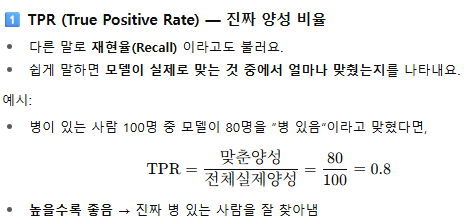

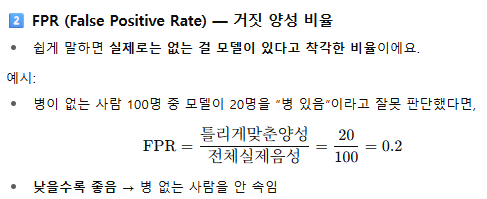

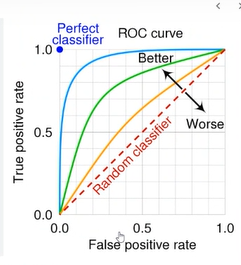




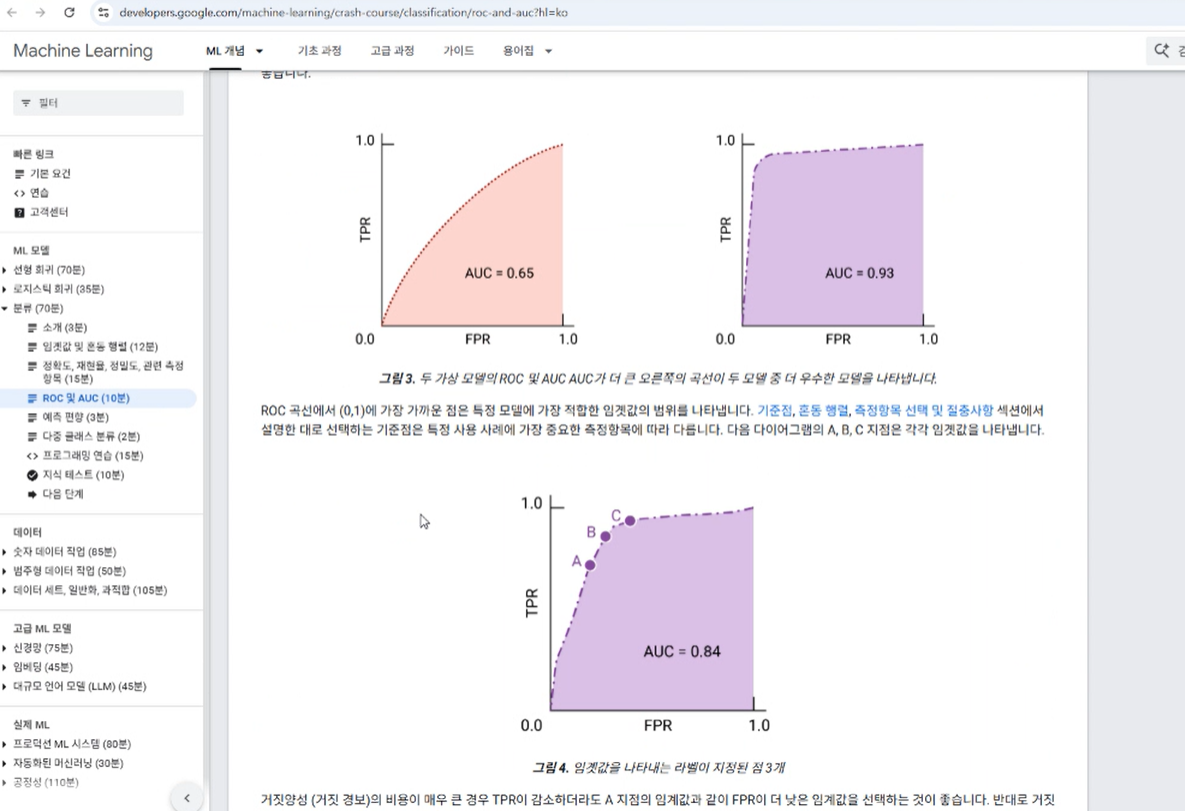


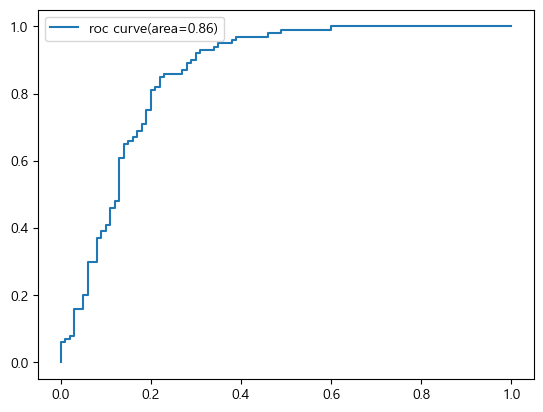

              precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.80      0.81      0.81       100

    accuracy                           0.81       200
   macro avg       0.81      0.81      0.80       200
weighted avg       0.81      0.81      0.80       200



In [35]:
from sklearn.datasets import make_classification
from sklearn.metrics import roc_curve, auc, classification_report
X, y= make_classification(n_samples=1000, n_features=20, n_informative=5, 
                          n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)

model=LogisticRegression()
model.fit(X_train, y_train)
y_pred_proba = model.predict_proba(X_test)[:,1] #양성클래스 확률 : [0,1] 각 클래스에 대한 확률 중 1에 대한 확률만 뽑아냄

# ROC AUC
# 실제값과 예측 확률을 사용 FPR, TPR
fpr, tpr, thesholds = roc_curve(y_test, y_pred_proba)
# fpr tpr 이용 auc를 계산
roc_auc = auc (fpr, tpr)

plt.plot(fpr, tpr, label=f'roc curve(area={roc_auc:.2f})')
plt.legend()
plt.show()

print(classification_report(y_test, model.predict(X_test)))